<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/Residue_survival_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,delta_tau,x,ln_dt,p_keep,zeta,A_tot,lambda_ov,lcc_ratio,rho_lcc,m_max,lcc_ratio_next,rho_lcc_next,m_max_next,nonlocal_frac
0,0.020000,-1.386294,-3.912023,0.026484,1.000000,0.222724,12.000000,0.003330,0.000000,29.8,0.006494,0.000000,0.000000,0.000000
1,0.022110,-1.285986,-3.811715,0.034107,0.614325,0.229713,12.000000,0.003996,0.000000,34.0,0.006494,0.000000,0.000000,0.000000
2,0.024443,-1.185678,-3.711406,0.043824,-0.245210,0.238252,12.000000,0.004440,0.000000,32.6,0.011688,0.000000,5.110402,0.000000
3,0.027022,-1.085370,-3.611098,0.056149,-0.915602,0.248783,12.000000,0.004218,0.000000,43.8,0.010390,0.000000,3.513768,0.000000
4,0.029873,-0.985061,-3.510790,0.071680,-0.879744,0.261904,12.000000,0.004883,0.000000,37.2,0.014286,0.000000,8.144335,0.000000
5,0.033025,-0.884753,-3.410482,0.091093,-0.165294,0.278440,12.000000,0.006437,0.000000,45.8,0.014286,0.000000,8.189040,0.000000
6,0.036510,-0.784445,-3.310173,0.115112,0.676655,0.299540,12.000000,0.008879,0.033333,47.2,0.015584,0.000000,8.867591,0.013312
7,0.040362,-0.684136,-3.209865,0.144457,0.996666,0.326835,12.000000,0.008435,0.000000,56.0,0.015584,0.000000,9.788215,0.047123
8,0.044621,-0.583828,-3.109557,0.179763,0.547898,0.362678,12.000000,0.010877,0.000000,52.0,0.018182,0.050000,11.848504,0.038023
9,0.049329,-0.483520,-3.009248,0.221465,-0.323491,0.410533,12.000000,0.019534,0.033162,58.8,0.025974,0.000000,14.494045,0.086858


omega = 9.064720283654388
IR points delta_tau>=0.2: 17
IR points (delta_tau>=0.2 & lcc_ratio>=0.95): 17
IR points kept: 17 out of 40


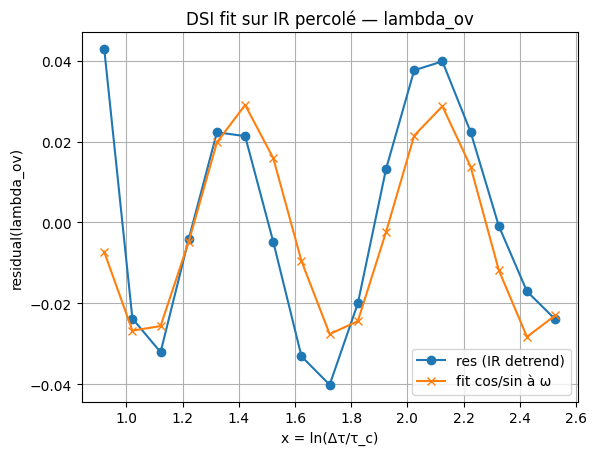

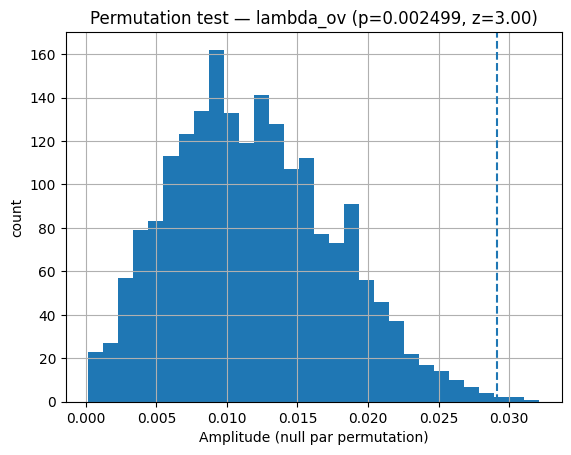

{'ycol': 'lambda_ov', 'n_points': 17, 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2, 'amp': 0.029164123147512773, 'r2': 0.6073085487607321, 'amp_null_mean': 0.011890377428527242, 'amp_null_std': 0.005754137188666438, 'z_score': 3.0019697397914915, 'p_value_perm': 0.0024987506246876563}
IR points kept: 17 out of 40


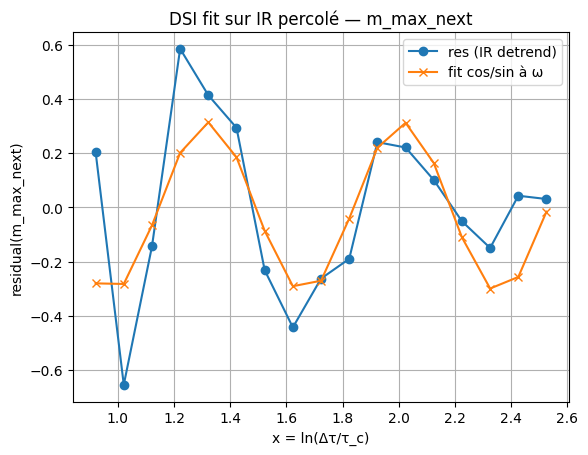

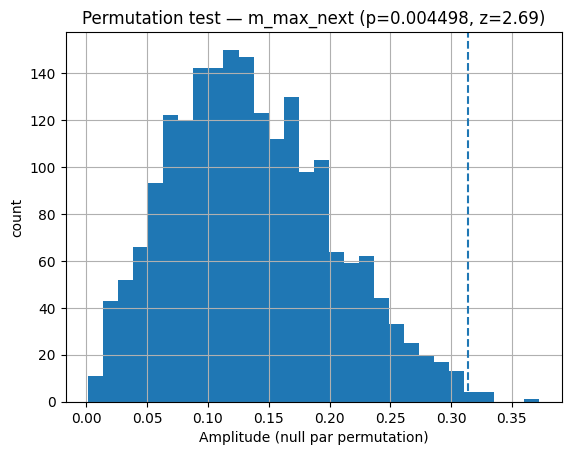

{'ycol': 'm_max_next', 'n_points': 17, 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2, 'amp': 0.3135525214504449, 'r2': 0.5308088504716046, 'amp_null_mean': 0.13648364821547057, 'amp_null_std': 0.06571511118426046, 'z_score': 2.694492484970251, 'p_value_perm': 0.004497751124437781}


In [ ]:
#  Cell 1
# ==========================================
# Colab — “Decisive” DSI test (percolated IR) with Kigami-like coarse-graining (Kron)
# 2D, bounded patch B_R (R = c t), l_p*l_p cells, 4-contact connectivity
# + stochastic UV (link percolation) + overlaps (integer conductances)
# + Residual IR DSI (non-zero amplitude when Δτ→1)
#
# Pipeline:
# 1) Generates a 4-connected 2D lattice in a B_R disk
# 2) Randomly removes links with probability 1 - p_keep(Δτ)
# 3) Assign conductances C_uv = 1 + Poisson(λ(Δτ)); λ carries a log-periodic residual DSI
# 4) Coarse-graining: 2×2 blocks, 1 anchor per block, regularized Kron reduction (Schur complement)
# 5) Forces locality to coarse by keeping only 4-neighbor edges between blocks
# 6) Measure: lcc_ratio, rho_loop on LCC, m_max_next, nonlocal_frac
# 7) Percolated IR DSI detection via fit sin/cos at imposed ω + permutation test
#
# Outputs:
# - g (DataFrame aggregated by delta_tau)
# - figures + dictionaries res_lambda, res_mmax
# ==========================================

# ---- deps ----

try:
    import scipy
    from scipy.sparse import coo_matrix, identity
    from scipy.sparse.linalg import splu
except Exception:
    !pip -q install scipy
    import scipy
    from scipy.sparse import coo_matrix, identity
    from scipy.sparse.linalg import splu

import math
from collections import deque, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Outils graph / métriques
# ============================================================

def induced_subgraph(V, E, V_keep):
    Vp = set(V_keep)
    Ep = [(u, v) for (u, v) in E if (u in Vp and v in Vp and u != v)]
    return list(Vp), Ep

def adjacency_on_subset(V_subset, E_subset):
    Vset = set(V_subset)
    adj = {v: set() for v in Vset}
    for (u, v) in E_subset:
        if u in Vset and v in Vset and u != v:
            adj[u].add(v)
            adj[v].add(u)
    return adj

def connected_components(adj, nodes_subset=None):
    nodes = set(adj.keys()) if nodes_subset is None else set(nodes_subset)
    seen, comps = set(), []
    for s in list(nodes):
        if s in seen:
            continue
        q = deque([s]); seen.add(s); comp = {s}
        while q:
            u = q.popleft()
            for v in adj[u]:
                if v in nodes and v not in seen:
                    seen.add(v); comp.add(v); q.append(v)
        comps.append(comp)
    return comps

def lcc_set(V_subset, E_subset):
    adj = adjacency_on_subset(V_subset, E_subset)
    comps = connected_components(adj, set(adj.keys()))
    if not comps:
        return set()
    return max(comps, key=len)

def metrics_full(V_subset, E_subset):
    Vset = set(V_subset)
    if not Vset:
        return dict(n=0, lcc_ratio=float("nan"), deg_max=float("nan"))
    adj = adjacency_on_subset(Vset, E_subset)
    comps = connected_components(adj, Vset)
    n = len(Vset)
    lcc = max((len(c) for c in comps), default=0)
    lcc_ratio = lcc / n
    deg_max = float(max((len(adj[v]) for v in Vset), default=0))
    return dict(n=int(n), lcc_ratio=float(lcc_ratio), deg_max=float(deg_max))

def rho_loop_lcc(V_subset, E_subset):
    L = lcc_set(V_subset, E_subset)
    n = len(L)
    if n == 0:
        return dict(n_lcc=0, rho_lcc=float("nan"))
    m = sum(1 for (u, v) in E_subset if u in L and v in L and u != v)
    b1 = m - n + 1  # connexe
    return dict(n_lcc=int(n), rho_lcc=float(b1 / n))

def interior_nodes_by_radius(node_radii, R, margin):
    cutoff = R - margin
    return [v for v, r in node_radii.items() if r <= cutoff]

def incidence_from_conductances(V_subset, E_subset, C):
    Vset = set(V_subset)
    if not Vset:
        return dict(m_max=float("nan"))
    m = {v: 0.0 for v in Vset}
    for (u, v) in E_subset:
        if u in Vset and v in Vset:
            key = (u, v) if u < v else (v, u)
            w = float(C.get(key, 1.0))
            m[u] += w; m[v] += w
    return dict(m_max=float(max(m.values())) if m else float("nan"))

# ============================================================
# 1) Lattice 2D 4-connexe dans un disque B_R + blocs 2×2
# ============================================================

def generate_lattice4_base(ell, R, lp=1.0):
    s = (2**ell) * lp
    M = int(math.floor(R / s))
    coords = []
    for i in range(-M, M+1):
        x = i*s
        for j in range(-M, M+1):
            y = j*s
            if x*x + y*y <= R*R + 1e-12:
                coords.append((i, j))

    id_of = {ij: k for k, ij in enumerate(coords)}
    V = list(range(len(coords)))
    pos = {id_of[(i, j)]: (i*s, j*s) for (i, j) in coords}
    radii = {vid: math.hypot(*pos[vid]) for vid in V}
    coord_of = {id_of[(i, j)]: (i, j) for (i, j) in coords}

    E_geo = []
    for (i, j) in coords:
        u = id_of[(i, j)]
        for di, dj in [(1,0), (-1,0), (0,1), (0,-1)]:
            nb = (i+di, j+dj)
            if nb in id_of:
                v = id_of[nb]
                if u < v:
                    E_geo.append((u, v))
    return V, E_geo, pos, radii, coord_of, id_of, s

def blocks_2x2(coord_of):
    blocks = defaultdict(list)
    for u, (i, j) in coord_of.items():
        I, J = (i // 2), (j // 2)
        blocks[(I, J)].append(u)

    IJ_list = list(blocks.keys())
    coarse_id_of = {IJ: k for k, IJ in enumerate(IJ_list)}
    IJ_of_coarse = {k: IJ for IJ, k in coarse_id_of.items()}

    return blocks, coarse_id_of, IJ_of_coarse

def choose_anchor_per_block(blocks, coarse_id_of):
    coarse_of_anchor_fine = {}
    for IJ, fine_list in blocks.items():
        cid = coarse_id_of[IJ]
        a = min(fine_list)
        coarse_of_anchor_fine[a] = cid
    keep_fine = list(coarse_of_anchor_fine.keys())
    return keep_fine, coarse_of_anchor_fine

def coarse_local_edges(IJ_of_coarse):
    id_of_IJ = {IJ: cid for cid, IJ in IJ_of_coarse.items()}
    E_loc = []
    for cid, (I, J) in IJ_of_coarse.items():
        for dI, dJ in [(1,0), (-1,0), (0,1), (0,-1)]:
            nb = (I+dI, J+dJ)
            if nb in id_of_IJ:
                cid2 = id_of_IJ[nb]
                if cid < cid2:
                    E_loc.append((cid, cid2))
    return E_loc

def coarse_radii_from_blocks(blocks, coarse_id_of, pos_fine):
    rad_c = {}
    for IJ, fine_list in blocks.items():
        cid = coarse_id_of[IJ]
        xs = [pos_fine[u][0] for u in fine_list]
        ys = [pos_fine[u][1] for u in fine_list]
        x = float(np.mean(xs)); y = float(np.mean(ys))
        rad_c[cid] = math.hypot(x, y)
    return rad_c

# ============================================================
# 2) DSI rémanente + p_keep calibré
# ============================================================

def p_keep_from_delta_tau(delta_tau, tau_c=0.08, p_c=0.5, kappa_keep=1.3):
    x = max(float(delta_tau), 1e-12)
    z = kappa_keep * math.log(x / tau_c)
    val = p_c + (1.0 - p_c) * math.tanh(z)
    return float(max(0.0, min(1.0, val)))

def zeta_dsi(delta_tau, tau_c=0.08, omega=9.064720283654388, phi=0.0):
    x = max(float(delta_tau), 1e-12)
    return math.cos(omega * math.log(x / tau_c) + phi)

def A_env_uv(delta_tau, tau_c=0.08, A_peak=1.0, A_uv_res=0.15, gamma_down=40.0, gamma_up=4.0):
    x = max(float(delta_tau), 1e-12)
    if x >= tau_c:
        return 0.0
    d = (tau_c - x)
    return A_peak * math.exp(-gamma_down * d) + A_uv_res * (1.0 - math.exp(-gamma_up * d))

def lambda_overlap_with_residual_dsi(delta_tau, tau_c=0.08,
                                    lam_bg_scale=1.2, alpha_bg=0.8,
                                    eps_lam=0.15,
                                    A_IR=0.10,       # résidu IR non nul
                                    A_peak=1.0, A_uv_res=0.15,
                                    omega=9.064720283654388, phi=0.0,
                                    lam_max=12.0):
    x = max(float(delta_tau), 1e-12)
    lam_bg = lam_bg_scale * (x ** (-alpha_bg))
    A_tot = A_IR + A_env_uv(x, tau_c=tau_c, A_peak=A_peak, A_uv_res=A_uv_res)
    z = zeta_dsi(x, tau_c=tau_c, omega=omega, phi=phi)
    lam = lam_bg * (1.0 + eps_lam * A_tot * z)
    lam = max(0.0, lam)
    return float(min(lam, lam_max)), float(A_tot), float(z)

def apply_stochastic_edges(E_geo, rng, delta_tau,
                           tau_c=0.08, p_c=0.5, kappa_keep=1.3,
                           lam_bg_scale=1.2, alpha_bg=0.8,
                           eps_lam=0.15, A_IR=0.10,
                           A_peak=1.0, A_uv_res=0.15,
                           omega=9.064720283654388, phi=0.0):
    p_keep = p_keep_from_delta_tau(delta_tau, tau_c=tau_c, p_c=p_c, kappa_keep=kappa_keep)
    lam, A_tot, z = lambda_overlap_with_residual_dsi(
        delta_tau, tau_c=tau_c,
        lam_bg_scale=lam_bg_scale, alpha_bg=alpha_bg,
        eps_lam=eps_lam, A_IR=A_IR,
        A_peak=A_peak, A_uv_res=A_uv_res,
        omega=omega, phi=phi
    )
    E = []
    C = {}
    for (u, v) in E_geo:
        if rng.random() <= p_keep:
            if u > v: u, v = v, u
            mult = 1 + int(rng.poisson(lam))
            E.append((u, v))
            C[(u, v)] = float(mult)
    st = dict(p_keep=float(p_keep), lambda_ov=float(lam), A_tot=float(A_tot), zeta=float(z))
    return E, C, st

# ============================================================
# 3) Laplacien + Kron (Schur complement) régularisé
# ============================================================

def laplacian_from_conductances(n_nodes, edges, C):
    rows, cols, data = [], [], []
    diag = np.zeros(n_nodes, dtype=float)

    for (u, v) in edges:
        key = (u, v) if u < v else (v, u)
        w = float(C.get(key, 1.0))
        diag[u] += w; diag[v] += w
        rows.extend([u, v]); cols.extend([v, u]); data.extend([-w, -w])

    rows.extend(list(range(n_nodes)))
    cols.extend(list(range(n_nodes)))
    data.extend(diag.tolist())

    L = coo_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes)).tocsc()
    L.sum_duplicates()
    return L

def kron_reduction(L, keep_idx, leak_reg=1e-9):
    n = L.shape[0]
    keep = np.array(sorted(set(keep_idx)), dtype=int)
    mask = np.ones(n, dtype=bool)
    mask[keep] = False
    elim = np.where(mask)[0]

    L_kk = L[keep[:, None], keep]
    if elim.size == 0:
        return keep, elim, L_kk.toarray()

    L_ki = L[keep[:, None], elim]
    L_ik = L[elim[:, None], keep]
    L_ii = L[elim[:, None], elim]

    diag = np.array(L_ii.diagonal())
    scale = float(np.mean(diag[diag > 0])) if np.any(diag > 0) else 1.0
    eps = leak_reg * scale
    L_ii_reg = (L_ii + eps * identity(elim.size, format="csc")).tocsc()

    lu = splu(L_ii_reg)
    B = L_ik.toarray()
    X = lu.solve(B)

    L_eff = L_kk.toarray() - (L_ki @ X)
    return keep, elim, L_eff

# ============================================================
# 4) Une simulation (delta_tau) + coarse-graining
# ============================================================

def run_one(delta_tau, seed,
            R=20, ell=0, lp=1.0, margin_factor=3.0,
            tau_c=0.08, p_c=0.5, kappa_keep=1.3,
            omega=9.064720283654388, phi=0.0,
            A_IR=0.10, eps_lam=0.15,
            leak_reg=1e-9, eps_w=1e-12):
    rng = np.random.default_rng(seed)

    # fine lattice
    V, E_geo, pos, radii, coord_of, id_of, s_ell = generate_lattice4_base(ell, R, lp=lp)

    # stoch edges + overlaps
    E, C, st = apply_stochastic_edges(
        E_geo, rng, delta_tau,
        tau_c=tau_c, p_c=p_c, kappa_keep=kappa_keep,
        eps_lam=eps_lam, A_IR=A_IR,
        omega=omega, phi=phi
    )

    # interior fine
    margin = margin_factor * s_ell
    V_int = interior_nodes_by_radius(radii, R, margin)
    V_int, E_int = induced_subgraph(V, E, V_int)

    metF = metrics_full(V_int, E_int)
    rhoF = rho_loop_lcc(V_int, E_int)
    incF = incidence_from_conductances(V_int, E_int, C)

    # coarse blocks + anchors
    blocks, coarse_id_of, IJ_of_coarse = blocks_2x2(coord_of)
    keep_fine, coarse_of_anchor_fine = choose_anchor_per_block(blocks, coarse_id_of)

    # Kron
    L = laplacian_from_conductances(len(V), E, C)
    keep_sorted, elim_sorted, L_eff = kron_reduction(L, keep_fine, leak_reg=leak_reg)

    coarse_ids_kept = [coarse_of_anchor_fine[fid] for fid in keep_sorted]
    idx_of_coarse = {cid: j for j, cid in enumerate(coarse_ids_kept)}

    # total effective off-diagonal weight (diagnostic non-local)
    K = L_eff.shape[0]
    total_off = 0.0
    for a in range(K):
        for b in range(a+1, K):
            w = -L_eff[a, b]
            if w > eps_w:
                total_off += float(w)

    # keep only local coarse edges
    E_loc = coarse_local_edges(IJ_of_coarse)
    Cc = {}
    local_off = 0.0
    for (a, b) in E_loc:
        ia = idx_of_coarse.get(a, None)
        ib = idx_of_coarse.get(b, None)
        if ia is None or ib is None:
            continue
        w = -L_eff[ia, ib]
        if w > eps_w:
            key = (a, b) if a < b else (b, a)
            Cc[key] = float(w)
            local_off += float(w)

    nonlocal_frac = float((total_off - local_off) / total_off) if total_off > 0 else float("nan")

    # coarse interior (ell+1)
    rad_c = coarse_radii_from_blocks(blocks, coarse_id_of, pos)
    s_next = (2**(ell+1)) * lp
    margin_next = margin_factor * s_next

    Vc_all = list(range(len(IJ_of_coarse)))
    Ec_all = list(Cc.keys())
    Vc_int = interior_nodes_by_radius(rad_c, R, margin_next)
    Vc_int, Ec_int = induced_subgraph(Vc_all, Ec_all, Vc_int)

    metC = metrics_full(Vc_int, Ec_int)
    rhoC = rho_loop_lcc(Vc_int, Ec_int)
    incC = incidence_from_conductances(Vc_int, Ec_int, Cc)

    return dict(
        delta_tau=float(delta_tau),
        x=float(math.log(max(delta_tau, 1e-12) / tau_c)),
        ln_dt=float(math.log(max(delta_tau, 1e-12))),
        p_keep=float(st["p_keep"]),
        zeta=float(st["zeta"]),
        A_tot=float(st["A_tot"]),
        lambda_ov=float(st["lambda_ov"]),
        # fine
        lcc_ratio=float(metF["lcc_ratio"]),
        rho_lcc=float(rhoF["rho_lcc"]),
        m_max=float(incF["m_max"]),
        # coarse
        lcc_ratio_next=float(metC["lcc_ratio"]),
        rho_lcc_next=float(rhoC["rho_lcc"]),
        m_max_next=float(incC["m_max"]),
        nonlocal_frac=float(nonlocal_frac),
    )

# ============================================================
# 5) Test DSI décisif en IR: fit sin/cos à ω imposé + permutation test
# ============================================================

def fit_dsi_on_ir(g, omega, ycol="lambda_ov",
                  tau_min=0.2, lcc_min=0.95,
                  poly_deg=2, n_perm=2000, seed=123):
    rng = np.random.default_rng(seed)

    sub = g[(g["delta_tau"] >= tau_min) & (g["lcc_ratio"] >= lcc_min)].copy()
    sub = sub.sort_values("x").reset_index(drop=True)

    print("IR points kept:", len(sub), "out of", len(g))
    if len(sub) < max(8, poly_deg + 4):
        raise ValueError(f"Trop peu de points IR percolés: {len(sub)}. "
                         f"Augmente N_DT / baisse tau_min ou lcc_min.")

    x = sub["x"].to_numpy()
    y = sub[ycol].to_numpy()

    # detrend sur IR uniquement
    coef = np.polyfit(x, y, deg=poly_deg)
    trend = np.polyval(coef, x)
    res = y - trend

    # fit à ω imposé
    A = np.column_stack([np.cos(omega * x), np.sin(omega * x)])
    ab, *_ = np.linalg.lstsq(A, res, rcond=None)
    fit = A @ ab
    amp = float(np.sqrt(ab[0]**2 + ab[1]**2))

    ss_tot = float(np.sum((res - np.mean(res))**2))
    ss_res = float(np.sum((res - fit)**2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else float("nan")

    # permutation null
    amps_null = np.empty(n_perm, dtype=float)
    for k in range(n_perm):
        res_perm = rng.permutation(res)
        abp, *_ = np.linalg.lstsq(A, res_perm, rcond=None)
        amps_null[k] = np.sqrt(abp[0]**2 + abp[1]**2)

    mu0 = float(np.mean(amps_null))
    sd0 = float(np.std(amps_null, ddof=1)) if n_perm > 1 else float("nan")
    z = (amp - mu0) / sd0 if sd0 > 0 else float("nan")
    pval = float((np.sum(amps_null >= amp) + 1) / (n_perm + 1))

    out = dict(
        ycol=ycol,
        n_points=int(len(sub)),
        tau_min=float(tau_min),
        lcc_min=float(lcc_min),
        poly_deg=int(poly_deg),
        amp=float(amp),
        r2=float(r2),
        amp_null_mean=float(mu0),
        amp_null_std=float(sd0),
        z_score=float(z),
        p_value_perm=float(pval),
    )

    # plots
    plt.figure()
    plt.plot(x, res, marker="o", label="res (IR detrend)")
    plt.plot(x, fit, marker="x", label="fit cos/sin à ω")
    plt.xlabel("x = ln(Δτ/τ_c)")
    plt.ylabel(f"residual({ycol})")
    plt.title(f"DSI fit sur IR percolé — {ycol}")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.hist(amps_null, bins=30)
    plt.axvline(amp, linestyle="--")
    plt.xlabel("Amplitude (null par permutation)")
    plt.ylabel("count")
    plt.title(f"Permutation test — {ycol} (p={pval:.4g}, z={z:.2f})")
    plt.grid(True)
    plt.show()

    return out

# ============================================================
# 6) RUN COMPLET (plus de points + n_rep=5)
# ============================================================

# Paramètres raisonnables (Kron global coûteux -> R modéré)
tau_c = 0.08
R = 20
ell = 0
margin_factor = 3.0

# DSI: λ=2 -> ω=2π/ln2
lambda_dsi = 2.0
omega = 2.0 * math.pi / math.log(lambda_dsi)
phi = 0.0

# DSI rémanente IR (à ajuster si besoin)
A_IR = 0.10
eps_lam = 0.15

# Échantillonnage log (plus dense)
N_DT = 40
delta_tau_list = np.exp(np.linspace(np.log(0.02), np.log(1.0), N_DT))

# Réplicats
n_rep = 5
base_seed = 1234

rows = []
for i, dt in enumerate(delta_tau_list):
    for r in range(n_rep):
        rows.append(run_one(
            float(dt),
            seed=base_seed + 1000*i + r,
            R=R, ell=ell, margin_factor=margin_factor,
            tau_c=tau_c,
            omega=omega, phi=phi,
            A_IR=A_IR, eps_lam=eps_lam
        ))

df = pd.DataFrame(rows)
g = df.groupby("delta_tau").mean(numeric_only=True).reset_index()
# x déjà produit dans run_one, mais groupby a moyenné; on le reconstruit proprement:
g["x"] = np.log(g["delta_tau"] / tau_c)

display(g)

print("omega =", omega)
print("IR points delta_tau>=0.2:", int((g["delta_tau"] >= 0.2).sum()))
print("IR points (delta_tau>=0.2 & lcc_ratio>=0.95):", int(((g["delta_tau"]>=0.2) & (g["lcc_ratio"]>=0.95)).sum()))

# ============================================================
# 7) Test décisif: d'abord ycol='lambda_ov', puis ycol='m_max_next'
# ============================================================

res_lambda = fit_dsi_on_ir(g, omega, ycol="lambda_ov", tau_min=0.2, lcc_min=0.95, poly_deg=2, n_perm=2000, seed=123)
print(res_lambda)

res_mmax = fit_dsi_on_ir(g, omega, ycol="m_max_next", tau_min=0.2, lcc_min=0.95, poly_deg=2, n_perm=2000, seed=456)
print(res_mmax)

,delta_tau,lcc_ratio,lambda_ov,m95,m95_next,m_max_next
30,0.405443,0.999778,2.450659,19.0,7.676359,8.778261
31,0.448222,1.000000,2.246197,18.0,7.223538,8.470762
32,0.495515,1.000000,2.082952,17.0,6.912674,8.088894
33,0.547797,1.000000,1.946822,16.8,6.695104,8.097574
34,0.605596,1.000000,1.815982,16.0,6.514044,7.689336
35,0.669494,1.000000,1.676956,15.0,6.175991,7.213795
36,0.740133,1.000000,1.532363,14.2,5.862128,6.738993
37,0.818226,1.000000,1.396015,13.6,5.480616,6.351045
38,0.904559,1.000000,1.280761,13.0,5.127237,6.286947
39,1.000000,1.000000,1.188866,12.2,4.991172,6.051119


IR points kept: 17 out of 40


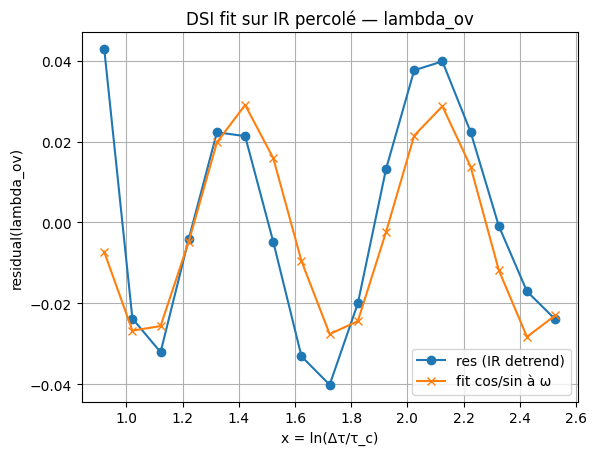

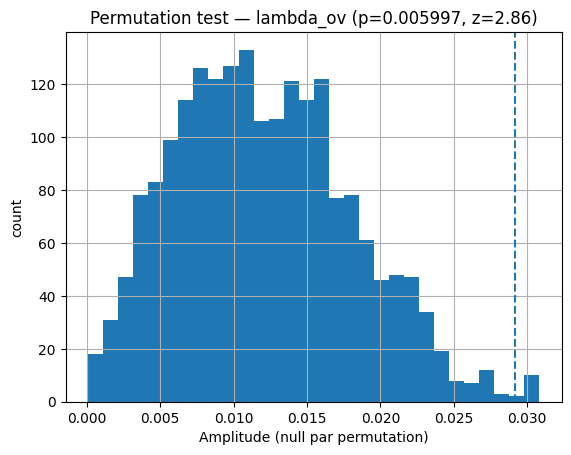

{'ycol': 'lambda_ov', 'n_points': 17, 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2, 'amp': 0.029164123147512773, 'r2': 0.6073085487607321, 'amp_null_mean': 0.012096697169343246, 'amp_null_std': 0.0059723636339033045, 'z_score': 2.8577338930407565, 'p_value_perm': 0.005997001499250375}
IR points kept: 17 out of 40


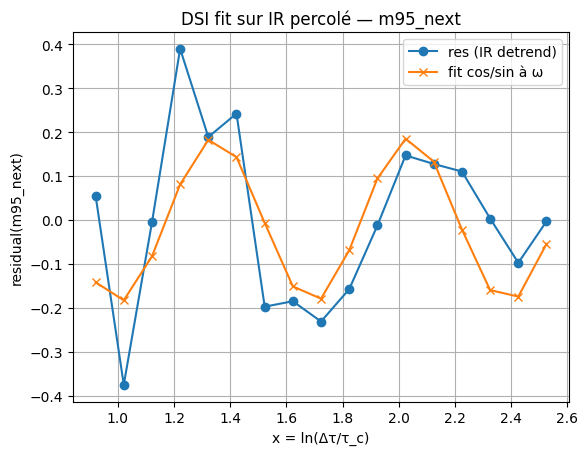

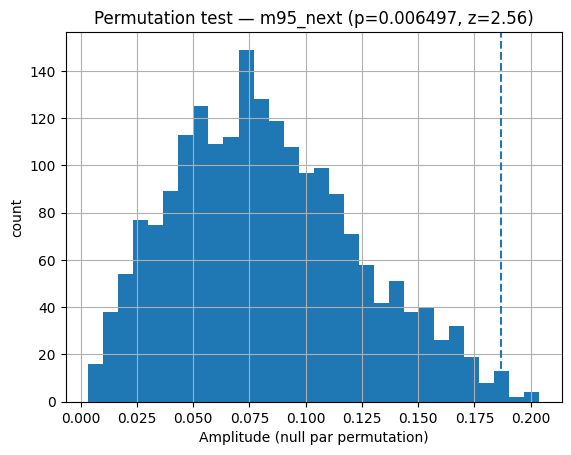

{'ycol': 'm95_next', 'n_points': 17, 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2, 'amp': 0.18667960267994332, 'r2': 0.5000752824584922, 'amp_null_mean': 0.08301821721997991, 'amp_null_std': 0.04056989655240329, 'z_score': 2.5551306330314683, 'p_value_perm': 0.006496751624187906}


In [ ]:
# cell 2
# ==========================================
# Ajout: remplacer m_max par un quantile robuste m95 (95e percentile) sur l'intérieur
# + version coarse m95_next
# Puis relancer le même test DSI sur ycol="m95_next" (et éventuellement "m95").
#
# Hypothèse: tu as déjà exécuté le "code complet" précédent dans le notebook
# (donc les fonctions run_one, fit_dsi_on_ir, etc. existent).
# ==========================================

import numpy as np

def incidence_stats_from_conductances(V_subset, E_subset, C, q=0.95):
    """
    Pour V_subset (intérieur): calcule m(v)=Σ C_vw,
    puis renvoie max et quantile q (par défaut 95%).
    """
    Vset = set(V_subset)
    if not Vset:
        return {"m_max": float("nan"), "m_q": float("nan")}
    m = {v: 0.0 for v in Vset}
    for (u, v) in E_subset:
        if u in Vset and v in Vset:
            key = (u, v) if u < v else (v, u)
            w = float(C.get(key, 1.0))
            m[u] += w
            m[v] += w
    vals = np.array(list(m.values()), dtype=float)
    return {"m_max": float(np.max(vals)), "m_q": float(np.quantile(vals, q))}

# --- remplacer run_one par une version qui calcule m95 et m95_next ---
def run_one_m95(delta_tau, seed,
                R=20, ell=0, lp=1.0, margin_factor=3.0,
                tau_c=0.08, p_c=0.5, kappa_keep=1.3,
                omega=9.064720283654388, phi=0.0,
                A_IR=0.10, eps_lam=0.15,
                leak_reg=1e-9, eps_w=1e-12, q=0.95):
    rng = np.random.default_rng(seed)

    # fine lattice
    V, E_geo, pos, radii, coord_of, id_of, s_ell = generate_lattice4_base(ell, R, lp=lp)
    E, C, st = apply_stochastic_edges(
        E_geo, rng, delta_tau,
        tau_c=tau_c, p_c=p_c, kappa_keep=kappa_keep,
        eps_lam=eps_lam, A_IR=A_IR,
        omega=omega, phi=phi
    )

    # interior fine
    margin = margin_factor * s_ell
    V_int = interior_nodes_by_radius(radii, R, margin)
    V_int, E_int = induced_subgraph(V, E, V_int)

    metF = metrics_full(V_int, E_int)
    rhoF = rho_loop_lcc(V_int, E_int)
    incF = incidence_stats_from_conductances(V_int, E_int, C, q=q)

    # coarse blocks + anchors
    blocks, coarse_id_of, IJ_of_coarse = blocks_2x2(coord_of)
    keep_fine, coarse_of_anchor_fine = choose_anchor_per_block(blocks, coarse_id_of)

    # Kron
    L = laplacian_from_conductances(len(V), E, C)
    keep_sorted, elim_sorted, L_eff = kron_reduction(L, keep_fine, leak_reg=leak_reg)

    coarse_ids_kept = [coarse_of_anchor_fine[fid] for fid in keep_sorted]
    idx_of_coarse = {cid: j for j, cid in enumerate(coarse_ids_kept)}

    # total effective off-diagonal weight
    K = L_eff.shape[0]
    total_off = 0.0
    for a in range(K):
        for b in range(a+1, K):
            w = -L_eff[a, b]
            if w > eps_w:
                total_off += float(w)

    # keep only local coarse edges
    E_loc = coarse_local_edges(IJ_of_coarse)
    Cc = {}
    local_off = 0.0
    for (a, b) in E_loc:
        ia = idx_of_coarse.get(a, None)
        ib = idx_of_coarse.get(b, None)
        if ia is None or ib is None:
            continue
        w = -L_eff[ia, ib]
        if w > eps_w:
            key = (a, b) if a < b else (b, a)
            Cc[key] = float(w)
            local_off += float(w)

    nonlocal_frac = float((total_off - local_off) / total_off) if total_off > 0 else float("nan")

    # coarse interior
    rad_c = coarse_radii_from_blocks(blocks, coarse_id_of, pos)
    s_next = (2**(ell+1)) * lp
    margin_next = margin_factor * s_next

    Vc_all = list(range(len(IJ_of_coarse)))
    Ec_all = list(Cc.keys())
    Vc_int = interior_nodes_by_radius(rad_c, R, margin_next)
    Vc_int, Ec_int = induced_subgraph(Vc_all, Ec_all, Vc_int)

    metC = metrics_full(Vc_int, Ec_int)
    rhoC = rho_loop_lcc(Vc_int, Ec_int)
    incC = incidence_stats_from_conductances(Vc_int, Ec_int, Cc, q=q)

    return dict(
        delta_tau=float(delta_tau),
        x=float(math.log(max(delta_tau, 1e-12) / tau_c)),
        ln_dt=float(math.log(max(delta_tau, 1e-12))),
        p_keep=float(st["p_keep"]),
        zeta=float(st["zeta"]),
        A_tot=float(st["A_tot"]),
        lambda_ov=float(st["lambda_ov"]),
        # fine
        lcc_ratio=float(metF["lcc_ratio"]),
        rho_lcc=float(rhoF["rho_lcc"]),
        m_max=float(incF["m_max"]),
        m95=float(incF["m_q"]),
        # coarse
        lcc_ratio_next=float(metC["lcc_ratio"]),
        rho_lcc_next=float(rhoC["rho_lcc"]),
        m_max_next=float(incC["m_max"]),
        m95_next=float(incC["m_q"]),
        nonlocal_frac=float(nonlocal_frac),
    )

# ==========================================
# Rerun léger (réutilise les mêmes paramètres que ton run décisif)
# ==========================================

N_DT = 40
delta_tau_list = np.exp(np.linspace(np.log(0.02), np.log(1.0), N_DT))
n_rep = 5
base_seed = 1234

rows = []
for i, dt in enumerate(delta_tau_list):
    for r in range(n_rep):
        rows.append(run_one_m95(
            float(dt),
            seed=base_seed + 1000*i + r,
            R=R, ell=ell, margin_factor=margin_factor,
            tau_c=tau_c,
            omega=omega, phi=phi,
            A_IR=A_IR, eps_lam=eps_lam,
            q=0.95
        ))

df = pd.DataFrame(rows)
g = df.groupby("delta_tau").mean(numeric_only=True).reset_index()
g["x"] = np.log(g["delta_tau"] / tau_c)

display(g[["delta_tau","lcc_ratio","lambda_ov","m95","m95_next","m_max_next"]].tail(10))

# ==========================================
# Tests DSI décisifs (IR percolé) sur m95_next
# ==========================================

res_lambda = fit_dsi_on_ir(g, omega, ycol="lambda_ov", tau_min=0.2, lcc_min=0.95, poly_deg=2, n_perm=2000, seed=111)
print(res_lambda)

res_m95 = fit_dsi_on_ir(g, omega, ycol="m95_next", tau_min=0.2, lcc_min=0.95, poly_deg=2, n_perm=2000, seed=222)
print(res_m95)

,delta_tau,lcc_ratio,lambda_ov,m95_next,m_max_next
50,0.550599,1.000000,1.940213,6.689160,7.987950
51,0.588344,1.000000,1.854215,6.442487,8.045024
52,0.628677,1.000000,1.765313,6.268250,7.431144
53,0.671774,0.999945,1.672087,6.068709,7.073404
54,0.717827,1.000000,1.576338,5.873176,6.950617
55,0.767036,0.999945,1.482073,5.685427,6.941883
56,0.819618,1.000000,1.393861,5.496033,6.616515
57,0.875806,1.000000,1.315173,5.331386,6.276814
58,0.935845,1.000000,1.247255,5.157803,6.126556
59,1.000000,1.000000,1.188866,5.026294,5.903502


IR points kept: 25 out of 60


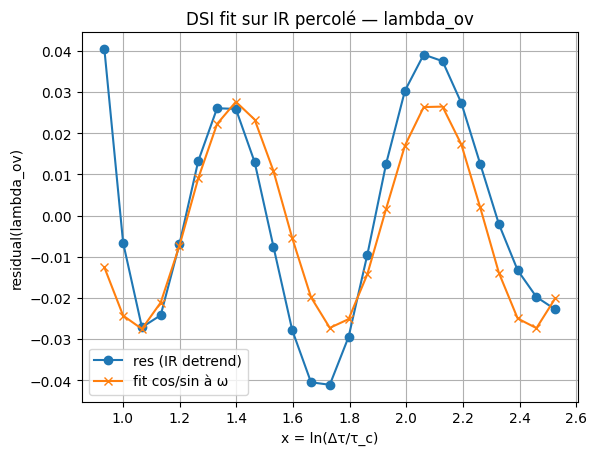

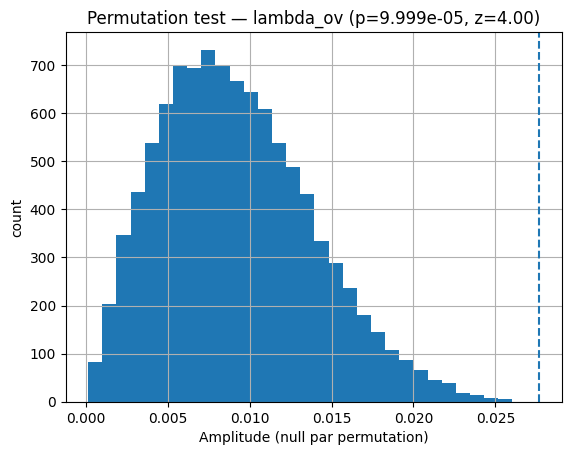

IR points kept: 25 out of 60


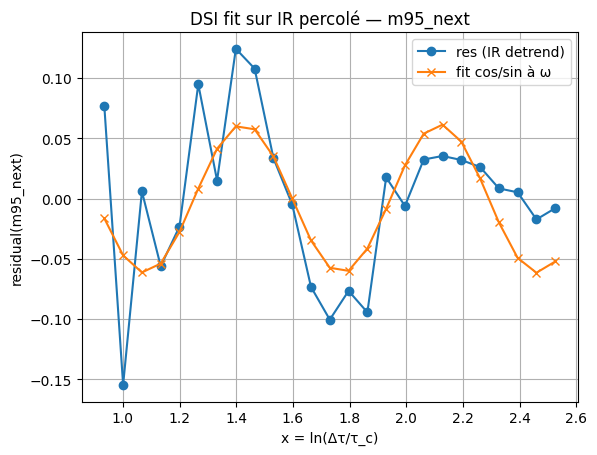

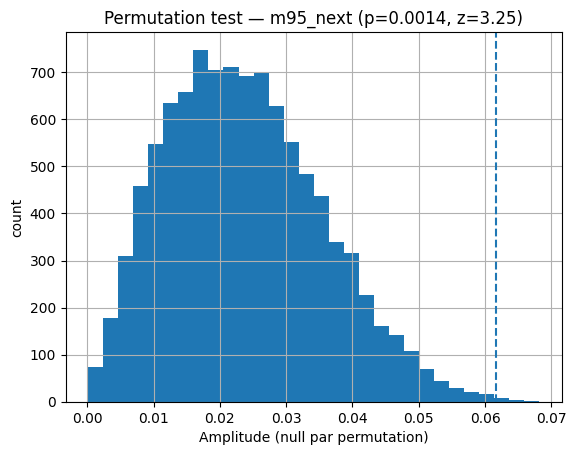

{'ycol': 'm95_next', 'n_points': 25, 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2, 'amp': 0.0615776378763151, 'r2': 0.46230441278653633, 'amp_null_mean': 0.02372258239203619, 'amp_null_std': 0.01164773414202734, 'z_score': 3.2499930907325867, 'p_value_perm': 0.0013998600139986002}


In [ ]:
# cell 3
# ==========================================
# Complete block (no dependency on external variables)
# Adds m95 (= 95% quantile) and m95_next
# + restarts the simulation + decisive DSI test on lambda_ov and m95_next



# Prerequisite : previous “complete code” :
#   - generate_lattice4_base
#   - apply_stochastic_edges
#   - induced_subgraph
#   - interior_nodes_by_radius
#   - metrics_full
#   - rho_loop_lcc
#   - blocks_2x2
#   - choose_anchor_per_block
#   - laplacian_from_conductances
#   - kron_reduction
#   - coarse_local_edges
#   - coarse_radii_from_blocks
#   - fit_dsi_on_ir
#
# This block redefines its own parameters (R, ell, etc.) to avoid NameError..
# ==========================================

import numpy as np
import pandas as pd
import math

# --------------------------
# Paramètres (définis ici)
# --------------------------
tau_c = 0.08
R = 20
ell = 0
margin_factor = 3.0

# DSI: λ=2 -> ω=2π/ln2
lambda_dsi = 2.0
omega = 2.0 * math.pi / math.log(lambda_dsi)
phi = 0.0

# Résidu IR DSI
A_IR = 0.10
eps_lam = 0.15

# Simulation
N_DT = 60
delta_tau_list = np.exp(np.linspace(np.log(0.02), np.log(1.0), N_DT))
n_rep = 20
base_seed = 1234

# --------------------------
# Robust incidence: max + quantile
# --------------------------
def incidence_stats_from_conductances(V_subset, E_subset, C, q=0.95):
    Vset = set(V_subset)
    if not Vset:
        return {"m_max": float("nan"), "m_q": float("nan")}
    m = {v: 0.0 for v in Vset}
    for (u, v) in E_subset:
        if u in Vset and v in Vset:
            key = (u, v) if u < v else (v, u)
            w = float(C.get(key, 1.0))
            m[u] += w
            m[v] += w
    vals = np.array(list(m.values()), dtype=float)
    return {"m_max": float(np.max(vals)), "m_q": float(np.quantile(vals, q))}

# --------------------------
# run_one_m95: a simulation pass
# --------------------------
def run_one_m95(delta_tau, seed,
                R=20, ell=0, lp=1.0, margin_factor=3.0,
                tau_c=0.08,
                omega=9.064720283654388, phi=0.0,
                A_IR=0.10, eps_lam=0.15,
                leak_reg=1e-9, eps_w=1e-12, q=0.95):
    rng = np.random.default_rng(seed)

    # fine lattice
    V, E_geo, pos, radii, coord_of, id_of, s_ell = generate_lattice4_base(ell, R, lp=lp)

    # stoch edges + overlaps
    E, C, st = apply_stochastic_edges(
        E_geo, rng, delta_tau,
        tau_c=tau_c,
        omega=omega, phi=phi,
        A_IR=A_IR, eps_lam=eps_lam
    )

    # interior fine
    margin = margin_factor * s_ell
    V_int = interior_nodes_by_radius(radii, R, margin)
    V_int, E_int = induced_subgraph(V, E, V_int)

    metF = metrics_full(V_int, E_int)
    rhoF = rho_loop_lcc(V_int, E_int)
    incF = incidence_stats_from_conductances(V_int, E_int, C, q=q)

    # coarse blocks + anchors
    blocks, coarse_id_of, IJ_of_coarse = blocks_2x2(coord_of)
    keep_fine, coarse_of_anchor_fine = choose_anchor_per_block(blocks, coarse_id_of)

    # Kron
    L = laplacian_from_conductances(len(V), E, C)
    keep_sorted, elim_sorted, L_eff = kron_reduction(L, keep_fine, leak_reg=leak_reg)

    coarse_ids_kept = [coarse_of_anchor_fine[fid] for fid in keep_sorted]
    idx_of_coarse = {cid: j for j, cid in enumerate(coarse_ids_kept)}

    # total effective off-diagonal weight
    K = L_eff.shape[0]
    total_off = 0.0
    for a in range(K):
        for b in range(a+1, K):
            w = -L_eff[a, b]
            if w > eps_w:
                total_off += float(w)

    # keep only local coarse edges
    E_loc = coarse_local_edges(IJ_of_coarse)
    Cc = {}
    local_off = 0.0
    for (a, b) in E_loc:
        ia = idx_of_coarse.get(a, None)
        ib = idx_of_coarse.get(b, None)
        if ia is None or ib is None:
            continue
        w = -L_eff[ia, ib]
        if w > eps_w:
            key = (a, b) if a < b else (b, a)
            Cc[key] = float(w)
            local_off += float(w)

    nonlocal_frac = float((total_off - local_off) / total_off) if total_off > 0 else float("nan")

    # coarse interior (ell+1)
    rad_c = coarse_radii_from_blocks(blocks, coarse_id_of, pos)
    s_next = (2**(ell+1)) * lp
    margin_next = margin_factor * s_next

    Vc_all = list(range(len(IJ_of_coarse)))
    Ec_all = list(Cc.keys())
    Vc_int = interior_nodes_by_radius(rad_c, R, margin_next)
    Vc_int, Ec_int = induced_subgraph(Vc_all, Ec_all, Vc_int)

    metC = metrics_full(Vc_int, Ec_int)
    rhoC = rho_loop_lcc(Vc_int, Ec_int)
    incC = incidence_stats_from_conductances(Vc_int, Ec_int, Cc, q=q)

    return dict(
        delta_tau=float(delta_tau),
        x=float(math.log(max(delta_tau, 1e-12) / tau_c)),
        ln_dt=float(math.log(max(delta_tau, 1e-12))),
        p_keep=float(st["p_keep"]),
        zeta=float(st["zeta"]),
        A_tot=float(st["A_tot"]),
        lambda_ov=float(st["lambda_ov"]),
        lcc_ratio=float(metF["lcc_ratio"]),
        rho_lcc=float(rhoF["rho_lcc"]),
        m_max=float(incF["m_max"]),
        m95=float(incF["m_q"]),
        lcc_ratio_next=float(metC["lcc_ratio"]),
        rho_lcc_next=float(rhoC["rho_lcc"]),
        m_max_next=float(incC["m_max"]),
        m95_next=float(incC["m_q"]),
        nonlocal_frac=float(nonlocal_frac),
    )

# --------------------------
# Rerun
# --------------------------
rows = []
for i, dt in enumerate(delta_tau_list):
    for r in range(n_rep):
        rows.append(run_one_m95(
            float(dt),
            seed=base_seed + 1000*i + r,
            R=R, ell=ell, margin_factor=margin_factor,
            tau_c=tau_c,
            omega=omega, phi=phi,
            A_IR=A_IR, eps_lam=eps_lam,
            q=0.95
        ))

df = pd.DataFrame(rows)
g = df.groupby("delta_tau").mean(numeric_only=True).reset_index()
g["x"] = np.log(g["delta_tau"] / tau_c)

display(g[["delta_tau","lcc_ratio","lambda_ov","m95_next","m_max_next"]].tail(10))

# --------------------------
# Tests DSI décisifs (IR percolé)
# --------------------------
res_lambda = fit_dsi_on_ir(g, omega, ycol="lambda_ov", tau_min=0.2, lcc_min=0.95, poly_deg=2, n_perm=10000, seed=111)
res_m95   = fit_dsi_on_ir(g, omega, ycol="m95_next",  tau_min=0.2, lcc_min=0.95, poly_deg=2, n_perm=10000, seed=222)
print(res_m95)

In [ ]:
# cell 4 residual ξ(𝒯)

import numpy as np

def check_residual_no_peak(g, ycol="m95_next", omega=1.0, tau_min=0.2, lcc_min=0.95, poly_deg=2,
                           n_perm=10000, seed=0):
    # 1) Sélection IR identique à ton protocole
    mask = (g["delta_tau"].values >= tau_min) & (g["lcc_ratio"].values >= lcc_min)
    x = g.loc[mask, "x"].values.astype(float)          # x = ln(delta_tau/tau_c) déjà dans g
    y = g.loc[mask, ycol].values.astype(float)

    # 2) Design matrix : polynôme + sin/cos
    cols = [np.ones_like(x)]
    for k in range(1, poly_deg + 1):
        cols.append(x**k)
    cols.append(np.sin(omega * x))
    cols.append(np.cos(omega * x))
    X = np.column_stack(cols)

    # 3) Moindres carrés
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat

    # 4) Amplitude "restante" à la même omega dans le résidu
    S = np.column_stack([np.sin(omega * x), np.cos(omega * x)])
    bc, *_ = np.linalg.lstsq(S, resid, rcond=None)
    amp_resid = float(np.sqrt(bc[0]**2 + bc[1]**2))

    # 5) Null par permutations (on permute le résidu vs x)
    rng = np.random.default_rng(seed)
    amps_null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        rp = resid[rng.permutation(len(resid))]
        bc_p, *_ = np.linalg.lstsq(S, rp, rcond=None)
        amps_null[i] = np.sqrt(bc_p[0]**2 + bc_p[1]**2)

    p_perm = float((np.sum(amps_null >= amp_resid) + 1) / (n_perm + 1))
    z = float((amp_resid - amps_null.mean()) / (amps_null.std(ddof=1) + 1e-12))

    return {
        "n_points": int(len(y)),
        "amp_resid": amp_resid,
        "amp_null_mean": float(amps_null.mean()),
        "amp_null_std": float(amps_null.std(ddof=1)),
        "z_score": z,
        "p_value_perm": p_perm,
        "beta": beta,   # utile si tu veux stocker les coeffs
    }

res_check = check_residual_no_peak(g, ycol="m95_next", omega=omega, tau_min=0.2, lcc_min=0.95,
                                   poly_deg=2, n_perm=10000, seed=333)
print(res_check)

{'n_points': 25, 'amp_resid': 8.405874613234956e-15, 'amp_null_mean': 0.015518165753721454, 'amp_null_std': 0.007447372913914612, 'z_score': -2.0837100452745316, 'p_value_perm': 1.0, 'beta': array([17.97825763, -8.33647067,  1.27979333,  0.02052767,  0.0737274 ])}


In [ ]:

# ============================================================
# Test "no residual peak at omega" (reviewer-proof)
# 1) Works on g (mean curve) OR on df (all replicates pooled)
# 2) Optional bootstrap: sample 1 replicate per delta_tau to get
#    a distribution of (amp_resid, p_value_perm)
#
# Assumes you already have:
#   - tau_c (float)
#   - omega (float)  # = 2π/ln(lambda_dsi)
#   - df (DataFrame) and/or g (DataFrame)
#   - g contains columns: delta_tau, lcc_ratio, x, ycol
#   - df contains columns: delta_tau, lcc_ratio, ycol
# ============================================================

import numpy as np
import pandas as pd

def _ensure_g(df=None, tau_c=None):
    """Build g from df if g is missing."""
    if "g" in globals() and isinstance(globals()["g"], pd.DataFrame):
        return globals()["g"]
    if df is None:
        df = globals().get("df", None)
    if df is None:
        raise NameError("Need df or g defined.")
    if tau_c is None:
        tau_c = globals().get("tau_c", None)
    if tau_c is None:
        raise NameError("Need tau_c defined to compute x = ln(delta_tau/tau_c).")
    _g = df.groupby("delta_tau").mean(numeric_only=True).reset_index()
    _g["x"] = np.log(_g["delta_tau"] / tau_c)
    globals()["g"] = _g
    return _g

def _fit_poly_sincos(x, y, omega, poly_deg=2):
    """OLS fit: y ~ poly(x) + sin(omega x) + cos(omega x). Returns beta, yhat, resid."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    cols = [np.ones_like(x)]
    for k in range(1, poly_deg + 1):
        cols.append(x**k)
    cols.append(np.sin(omega * x))
    cols.append(np.cos(omega * x))
    X = np.column_stack(cols)

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat
    return beta, yhat, resid

def check_residual_no_peak_xy(x, y, omega, poly_deg=2, n_perm=10000, seed=0):
    """
    Core test:
      - Fit poly+sin/cos at omega
      - Compute residual
      - Regress residual on sin/cos at omega to estimate remaining amplitude
      - Permutation test of that remaining amplitude
    """
    beta, yhat, resid = _fit_poly_sincos(x, y, omega=omega, poly_deg=poly_deg)

    S = np.column_stack([np.sin(omega * x), np.cos(omega * x)])
    bc, *_ = np.linalg.lstsq(S, resid, rcond=None)
    amp_resid = float(np.sqrt(bc[0]**2 + bc[1]**2))

    rng = np.random.default_rng(seed)
    amps_null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        rp = resid[rng.permutation(len(resid))]
        bc_p, *_ = np.linalg.lstsq(S, rp, rcond=None)
        amps_null[i] = np.sqrt(bc_p[0]**2 + bc_p[1]**2)

    p_perm = float((np.sum(amps_null >= amp_resid) + 1) / (n_perm + 1))
    z = float((amp_resid - amps_null.mean()) / (amps_null.std(ddof=1) + 1e-12))

    return {
        "n_points": int(len(y)),
        "amp_resid": amp_resid,
        "amp_null_mean": float(amps_null.mean()),
        "amp_null_std": float(amps_null.std(ddof=1)),
        "z_score": z,
        "p_value_perm": p_perm,
        "beta": beta,
    }

def check_residual_no_peak_on_g(g, ycol="m95_next", omega=1.0, tau_min=0.2, lcc_min=0.95,
                                poly_deg=2, n_perm=10000, seed=0):
    mask = (g["delta_tau"].values >= tau_min) & (g["lcc_ratio"].values >= lcc_min)
    x = g.loc[mask, "x"].values.astype(float)
    y = g.loc[mask, ycol].values.astype(float)
    out = check_residual_no_peak_xy(x, y, omega=omega, poly_deg=poly_deg, n_perm=n_perm, seed=seed)
    out.update({"scope": "g(mean)", "ycol": ycol, "tau_min": tau_min, "lcc_min": lcc_min, "poly_deg": poly_deg})
    return out

def check_residual_no_peak_on_df(df, tau_c, ycol="m95_next", omega=1.0, tau_min=0.2, lcc_min=0.95,
                                 poly_deg=2, n_perm=10000, seed=0):
    """
    Same test but on pooled replicates (no averaging).
    Uses x = ln(delta_tau/tau_c) for each row.
    """
    mask = (df["delta_tau"].values >= tau_min) & (df["lcc_ratio"].values >= lcc_min)
    x = np.log(df.loc[mask, "delta_tau"].values.astype(float) / float(tau_c))
    y = df.loc[mask, ycol].values.astype(float)
    out = check_residual_no_peak_xy(x, y, omega=omega, poly_deg=poly_deg, n_perm=n_perm, seed=seed)
    out.update({"scope": "df(pooled)", "ycol": ycol, "tau_min": tau_min, "lcc_min": lcc_min, "poly_deg": poly_deg})
    return out

def bootstrap_no_peak_from_df(df, tau_c, ycol="m95_next", omega=1.0, tau_min=0.2, lcc_min=0.95,
                              poly_deg=2, n_perm=2000, B=200, seed=0):
    """
    Bootstrap "one replicate per delta_tau" to mimic a full curve without averaging:
      For each bootstrap b:
        - for each delta_tau group, sample 1 row
        - build a pseudo-curve g_b and run the same residual-no-peak test on g_b
    Returns a DataFrame of results (amp_resid, p_value_perm, ...).
    """
    rng = np.random.default_rng(seed)

    # keep only IR-eligible rows
    df_ir = df[(df["delta_tau"] >= tau_min) & (df["lcc_ratio"] >= lcc_min)].copy()
    if df_ir.empty:
        raise ValueError("No IR rows after filtering; lower tau_min/lcc_min or check df columns.")

    groups = list(df_ir.groupby("delta_tau"))
    if len(groups) < (poly_deg + 3):
        raise ValueError("Not enough distinct delta_tau points after filtering to fit poly+sin/cos.")

    rows = []
    for b in range(B):
        sampled = []
        for dt, sub in groups:
            sampled.append(sub.iloc[rng.integers(0, len(sub))])
        g_b = pd.DataFrame(sampled)
        g_b["x"] = np.log(g_b["delta_tau"].values.astype(float) / float(tau_c))
        x = g_b["x"].values.astype(float)
        y = g_b[ycol].values.astype(float)

        out = check_residual_no_peak_xy(x, y, omega=omega, poly_deg=poly_deg, n_perm=n_perm, seed=int(rng.integers(1, 10**9)))
        out.update({"b": b, "n_dt": int(g_b.shape[0])})
        rows.append(out)

    return pd.DataFrame(rows)

# ----------------------------
# RUN (examples)
# ----------------------------
# 1) On g (mean curve)
g = _ensure_g(df=globals().get("df", None), tau_c=globals().get("tau_c", None))
res_g = check_residual_no_peak_on_g(g, ycol="m95_next", omega=omega, tau_min=0.2, lcc_min=0.95,
                                    poly_deg=2, n_perm=10000, seed=333)
print("NO-PEAK on g:", res_g)

# 2) On df (pooled replicates)
if "df" in globals():
    res_df = check_residual_no_peak_on_df(df, tau_c=tau_c, ycol="m95_next", omega=omega,
                                          tau_min=0.2, lcc_min=0.95, poly_deg=2,
                                          n_perm=10000, seed=444)
    print("NO-PEAK on df:", res_df)

# 3) Bootstrap distribution (reviewer-proof, recommended)
#    (use smaller n_perm first to keep runtime reasonable)
if "df" in globals():
    boot = bootstrap_no_peak_from_df(df, tau_c=tau_c, ycol="m95_next", omega=omega,
                                     tau_min=0.2, lcc_min=0.95, poly_deg=2,
                                     n_perm=10000, B=200, seed=555)
    print(boot[["amp_resid","p_value_perm","z_score"]].describe())
    print("Fraction p>0.05:", float((boot["p_value_perm"] > 0.05).mean()))

NO-PEAK on g: {'n_points': 25, 'amp_resid': 8.405874613234956e-15, 'amp_null_mean': 0.015518165753721454, 'amp_null_std': 0.007447372913914612, 'z_score': -2.0837100452745316, 'p_value_perm': 1.0, 'beta': array([17.97825763, -8.33647067,  1.27979333,  0.02052767,  0.0737274 ]), 'scope': 'g(mean)', 'ycol': 'm95_next', 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2}
NO-PEAK on df: {'n_points': 500, 'amp_resid': 1.0763386644076187e-14, 'amp_null_mean': 0.019146586125340502, 'amp_null_std': 0.010017876551681635, 'z_score': -1.9112419707552182, 'p_value_perm': 1.0, 'beta': array([17.97825763, -8.33647067,  1.27979333,  0.02052767,  0.0737274 ]), 'scope': 'df(pooled)', 'ycol': 'm95_next', 'tau_min': 0.2, 'lcc_min': 0.95, 'poly_deg': 2}
          amp_resid  p_value_perm     z_score
count  2.000000e+02         200.0  200.000000
mean   8.199583e-15           1.0   -2.013917
std    1.205729e-15           0.0    0.031880
min    5.243953e-15           1.0   -2.191897
25%    7.446853e-15           

In [ ]:
import numpy as np
import pandas as pd
import math

def build_g_if_missing():
    # Si g existe déjà, on le garde
    if "g" in globals() and isinstance(globals()["g"], pd.DataFrame):
        return globals()["g"]

    # Sinon, si df existe, on reconstruit g
    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
        _g = df.groupby("delta_tau").mean(numeric_only=True).reset_index()
        _g["x"] = np.log(_g["delta_tau"] / tau_c)
        globals()["g"] = _g
        return _g

    # Sinon, on relance la simulation (nécessite run_one_m95 et les paramètres déjà définis)
    rows = []
    for i, dt in enumerate(delta_tau_list):
        for r in range(n_rep):
            rows.append(run_one_m95(
                float(dt),
                seed=base_seed + 1000*i + r,
                R=R, ell=ell, margin_factor=margin_factor,
                tau_c=tau_c,
                omega=omega, phi=phi,
                A_IR=A_IR, eps_lam=eps_lam,
                q=0.95
            ))
    _df = pd.DataFrame(rows)
    globals()["df"] = _df
    _g = _df.groupby("delta_tau").mean(numeric_only=True).reset_index()
    _g["x"] = np.log(_g["delta_tau"] / tau_c)
    globals()["g"] = _g
    return _g

def check_residual_no_peak(g, ycol="m95_next", omega=1.0, tau_min=0.2, lcc_min=0.95, poly_deg=2,
                           n_perm=10000, seed=0):
    mask = (g["delta_tau"].values >= tau_min) & (g["lcc_ratio"].values >= lcc_min)
    x = g.loc[mask, "x"].values.astype(float)
    y = g.loc[mask, ycol].values.astype(float)

    cols = [np.ones_like(x)]
    for k in range(1, poly_deg + 1):
        cols.append(x**k)
    cols.append(np.sin(omega * x))
    cols.append(np.cos(omega * x))
    X = np.column_stack(cols)

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat

    S = np.column_stack([np.sin(omega * x), np.cos(omega * x)])
    bc, *_ = np.linalg.lstsq(S, resid, rcond=None)
    amp_resid = float(np.sqrt(bc[0]**2 + bc[1]**2))

    rng = np.random.default_rng(seed)
    amps_null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        rp = resid[rng.permutation(len(resid))]
        bc_p, *_ = np.linalg.lstsq(S, rp, rcond=None)
        amps_null[i] = np.sqrt(bc_p[0]**2 + bc_p[1]**2)

    p_perm = float((np.sum(amps_null >= amp_resid) + 1) / (n_perm + 1))
    z = float((amp_resid - amps_null.mean()) / (amps_null.std(ddof=1) + 1e-12))

    return {
        "ycol": ycol,
        "n_points": int(len(y)),
        "tau_min": float(tau_min),
        "lcc_min": float(lcc_min),
        "poly_deg": int(poly_deg),
        "amp_resid": amp_resid,
        "amp_null_mean": float(amps_null.mean()),
        "amp_null_std": float(amps_null.std(ddof=1)),
        "z_score": z,
        "p_value_perm": p_perm,
    }

# --- Run ---
g = build_g_if_missing()
res_check = check_residual_no_peak(g, ycol="m95_next", omega=omega, tau_min=0.2, lcc_min=0.95,
                                   poly_deg=2, n_perm=10000, seed=333)
print(res_check)

{'n_points': 25, 'amp_resid': 8.405874613234956e-15, 'amp_null_mean': 0.015518165753721454, 'amp_null_std': 0.007447372913914612, 'z_score': -2.0837100452745316, 'p_value_perm': 1.0, 'beta': array([17.97825763, -8.33647067,  1.27979333,  0.02052767,  0.0737274 ])}


In [ ]:

import numpy as np

def _fit_poly_sincos(x, y, omega, poly_deg=2):
    x = np.asarray(x, float); y = np.asarray(y, float)
    cols = [np.ones_like(x)]
    for k in range(1, poly_deg+1):
        cols.append(x**k)
    cols += [np.sin(omega*x), np.cos(omega*x)]
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def _predict_poly_sincos(x, beta, omega, poly_deg=2):
    x = np.asarray(x, float)
    cols = [np.ones_like(x)]
    for k in range(1, poly_deg+1):
        cols.append(x**k)
    cols += [np.sin(omega*x), np.cos(omega*x)]
    X = np.column_stack(cols)
    return X @ beta

def _amp_at_omega(x, r, omega):
    x = np.asarray(x, float); r = np.asarray(r, float)
    S = np.column_stack([np.sin(omega*x), np.cos(omega*x)])
    bc, *_ = np.linalg.lstsq(S, r, rcond=None)
    return float(np.sqrt(bc[0]**2 + bc[1]**2))

def no_peak_cv(g, ycol="m95_next", omega=1.0, tau_min=0.2, lcc_min=0.95, poly_deg=2,
               frac_train=0.6, n_splits=200, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)

    mask = (g["delta_tau"].values >= tau_min) & (g["lcc_ratio"].values >= lcc_min)
    x_all = g.loc[mask, "x"].values.astype(float)
    y_all = g.loc[mask, ycol].values.astype(float)

    n = len(y_all)
    n_tr = max(int(frac_train*n), poly_deg+3)  # assez pour fit

    pvals = []
    amps = []
    for s in range(n_splits):
        idx = rng.permutation(n)
        tr = idx[:n_tr]
        te = idx[n_tr:]

        x_tr, y_tr = x_all[tr], y_all[tr]
        x_te, y_te = x_all[te], y_all[te]

        beta = _fit_poly_sincos(x_tr, y_tr, omega=omega, poly_deg=poly_deg)
        yhat_te = _predict_poly_sincos(x_te, beta, omega=omega, poly_deg=poly_deg)
        r_te = y_te - yhat_te

        amp = _amp_at_omega(x_te, r_te, omega)
        amps.append(amp)

        # permutation null on test residual
        amps_null = np.empty(n_perm, float)
        for i in range(n_perm):
            rp = r_te[rng.permutation(len(r_te))]
            amps_null[i] = _amp_at_omega(x_te, rp, omega)
        p = (np.sum(amps_null >= amp) + 1) / (n_perm + 1)
        pvals.append(float(p))

    return {
        "n_points": int(n),
        "n_splits": int(n_splits),
        "amp_mean": float(np.mean(amps)),
        "amp_med": float(np.median(amps)),
        "pval_mean": float(np.mean(pvals)),
        "frac_p_gt_0_05": float(np.mean(np.array(pvals) > 0.05)),
        "frac_p_lt_0_01": float(np.mean(np.array(pvals) < 0.01)),
    }

res_cv = no_peak_cv(g, ycol="m95_next", omega=omega, tau_min=0.2, lcc_min=0.95,
                    poly_deg=2, frac_train=0.6, n_splits=200, n_perm=2000, seed=777)
print(res_cv)

{'n_points': 25, 'n_splits': 200, 'amp_mean': 0.040527375098305035, 'amp_med': 0.038595670505514976, 'pval_mean': 0.3930059970014993, 'frac_p_gt_0_05': 0.885, 'frac_p_lt_0_01': 0.03}


In [ ]:
# ============================================================
# Test "bande" autour de ω0 : scan log-fréquentiel (IR)
# Objectif : voir si la signature est mono-fréquence (pic étroit)
#            ou en bande (plateau / plusieurs pics proches)
#
# Entrées attendues :
#   - g : DataFrame avec colonnes ["delta_tau","lcc_ratio","x", ycol]
#         où x = ln(delta_tau/tau_c)
#   - tau_c, omega (ω0) déjà définis dans ton notebook
# ============================================================

import numpy as np
import pandas as pd

def ensure_g():
    if "g" in globals() and isinstance(globals()["g"], pd.DataFrame):
        return globals()["g"]
    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
        _g = df.groupby("delta_tau").mean(numeric_only=True).reset_index()
        _g["x"] = np.log(_g["delta_tau"] / tau_c)
        globals()["g"] = _g
        return _g
    raise NameError("Ni g ni df ne sont définis. Construis df/g d'abord.")

def amp_at_omega_on_ir(g, omega, ycol="m95_next", tau_min=0.2, lcc_min=0.95, poly_deg=2,
                      n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)

    mask = (g["delta_tau"].values >= tau_min) & (g["lcc_ratio"].values >= lcc_min)
    x = g.loc[mask, "x"].values.astype(float)
    y = g.loc[mask, ycol].values.astype(float)
    n = len(y)

    # 1) détrend polynomial
    Xp = np.column_stack([x**k for k in range(poly_deg+1)])  # [1, x, x^2, ...]
    bp, *_ = np.linalg.lstsq(Xp, y, rcond=None)
    y_detr = y - (Xp @ bp)

    # 2) fit sin/cos sur le résidu détrendé
    S = np.column_stack([np.sin(omega*x), np.cos(omega*x)])
    bc, *_ = np.linalg.lstsq(S, y_detr, rcond=None)
    amp = float(np.sqrt(bc[0]**2 + bc[1]**2))

    # 3) permutation null : on permute y_detr vs x
    null = np.empty(n_perm, float)
    for i in range(n_perm):
        yp = y_detr[rng.permutation(n)]
        bc_p, *_ = np.linalg.lstsq(S, yp, rcond=None)
        null[i] = np.sqrt(bc_p[0]**2 + bc_p[1]**2)

    p_perm = float((np.sum(null >= amp) + 1) / (n_perm + 1))
    z = float((amp - null.mean()) / (null.std(ddof=1) + 1e-12))

    return dict(n_points=int(n), amp=amp,
                amp_null_mean=float(null.mean()),
                amp_null_std=float(null.std(ddof=1)),
                z_score=z, p_value_perm=p_perm)

def benjamini_hochberg(pvals):
    """FDR BH correction; returns adjusted p-values in original order."""
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = np.empty(n, float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, float)
    out[order] = np.clip(adj, 0.0, 1.0)
    return out

def scan_band(g, omega0, ycol="m95_next",
              rel_span=0.4, n_omega=41,
              tau_min=0.2, lcc_min=0.95, poly_deg=2,
              n_perm=2000, seed=123):
    # grille ω autour de ω0
    q = np.linspace(1.0-rel_span, 1.0+rel_span, n_omega)
    omega_grid = omega0 * q

    rows = []
    for j, w in enumerate(omega_grid):
        r = amp_at_omega_on_ir(g, w, ycol=ycol,
                              tau_min=tau_min, lcc_min=lcc_min,
                              poly_deg=poly_deg, n_perm=n_perm,
                              seed=seed + 1000*j)
        r["omega"] = float(w)
        r["q"] = float(w/omega0)
        # lambda_eff via ω = 2π / ln λ  =>  λ = exp(2π/ω)
        r["lambda_eff"] = float(np.exp(2.0*np.pi / w))
        rows.append(r)

    out = pd.DataFrame(rows)
    out["p_fdr"] = benjamini_hochberg(out["p_value_perm"].values)

    # détection d'intervalle(s) significatifs
    sig = out["p_fdr"].values < 0.05
    intervals = []
    if np.any(sig):
        idx = np.where(sig)[0]
        # regrouper en segments contigus
        start = idx[0]
        prev = idx[0]
        for k in idx[1:]:
            if k == prev + 1:
                prev = k
            else:
                intervals.append((start, prev))
                start = prev = k
        intervals.append((start, prev))

    return out, intervals

# ----------------------------
# RUN
# ----------------------------
g = ensure_g()

omega0 = omega  # ta valeur centrale (2π/ln2 si lambda_dsi=2)
band_df, intervals = scan_band(
    g, omega0=omega0, ycol="m95_next",
    rel_span=0.4, n_omega=41,          # ±40% autour de ω0
    tau_min=0.2, lcc_min=0.95,
    poly_deg=2,
    n_perm=2000, seed=2026
)

display(band_df[["q","omega","lambda_eff","amp","z_score","p_value_perm","p_fdr"]])

print("Segments significatifs (FDR<0.05) en indices:", intervals)
if intervals:
    for a,b in intervals:
        w1, w2 = band_df.loc[a,"omega"], band_df.loc[b,"omega"]
        q1, q2 = band_df.loc[a,"q"], band_df.loc[b,"q"]
        print(f"  - Bande: ω ∈ [{w1:.3g}, {w2:.3g}]  (q ∈ [{q1:.3g}, {q2:.3g}])")

,q,omega,lambda_eff,amp,z_score,p_value_perm,p_fdr
0,0.60,5.438832,3.174802,0.035877,1.077873,0.156422,0.194342
1,0.62,5.620127,3.058667,0.038468,1.328096,0.105447,0.139463
2,0.64,5.801421,2.953652,0.041275,1.523572,0.074463,0.105275
3,0.66,5.982715,2.858288,0.044269,1.814407,0.046977,0.068787
4,0.68,6.164010,2.771349,0.047357,2.020891,0.033483,0.052801
5,0.70,6.345304,2.691800,0.050399,2.290015,0.019490,0.031964
6,0.72,6.526599,2.618769,0.053242,2.614553,0.008496,0.015833
7,0.74,6.707893,2.551510,0.055754,2.745407,0.007496,0.015833
8,0.76,6.889187,2.489385,0.057855,2.830800,0.004998,0.011383
9,0.78,7.070482,2.431845,0.059521,2.962111,0.004998,0.011383


Segments significatifs (FDR<0.05) en indices: [(np.int64(5), np.int64(29))]
  - Bande: ω ∈ [6.35, 10.7]  (q ∈ [0.7, 1.18])


In [ ]:
# ============================================================
Scan “band” around ω0 ON df (pooled replicates)
# -> same outputs: DataFrame + significant segments (FDR<0.05)
#
# Prerequisites:
#   - df: DataFrame with columns [“delta_tau”,“lcc_ratio”, ycol]
#   - tau_c: float
#   - omega: ω0 (e.g., 2π/ln2)
# ============================================================

import numpy as np
import pandas as pd

def benjamini_hochberg(pvals):
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = np.empty(n, float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, float)
    out[order] = np.clip(adj, 0.0, 1.0)
    return out

def amp_at_omega_on_ir_df(df, tau_c, omega, ycol="m95_next",
                         tau_min=0.2, lcc_min=0.95,
                         poly_deg=2, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)

    mask = (df["delta_tau"].values >= tau_min) & (df["lcc_ratio"].values >= lcc_min)
    x = np.log(df.loc[mask, "delta_tau"].values.astype(float) / float(tau_c))
    y = df.loc[mask, ycol].values.astype(float)
    n = len(y)

    # Detrend polynomial in x
    Xp = np.column_stack([x**k for k in range(poly_deg+1)])  # [1, x, x^2, ...]
    bp, *_ = np.linalg.lstsq(Xp, y, rcond=None)
    y_detr = y - (Xp @ bp)

    # Fit sin/cos at omega
    S = np.column_stack([np.sin(omega*x), np.cos(omega*x)])
    bc, *_ = np.linalg.lstsq(S, y_detr, rcond=None)
    amp = float(np.sqrt(bc[0]**2 + bc[1]**2))

    # Permutation null (shuffle y_detr vs x)
    null = np.empty(n_perm, float)
    for i in range(n_perm):
        yp = y_detr[rng.permutation(n)]
        bc_p, *_ = np.linalg.lstsq(S, yp, rcond=None)
        null[i] = np.sqrt(bc_p[0]**2 + bc_p[1]**2)

    p_perm = float((np.sum(null >= amp) + 1) / (n_perm + 1))
    z = float((amp - null.mean()) / (null.std(ddof=1) + 1e-12))

    return dict(n_points=int(n), amp=amp,
                amp_null_mean=float(null.mean()),
                amp_null_std=float(null.std(ddof=1)),
                z_score=z, p_value_perm=p_perm)

def scan_band_df(df, tau_c, omega0, ycol="m95_next",
                 rel_span=0.4, n_omega=41,
                 tau_min=0.2, lcc_min=0.95, poly_deg=2,
                 n_perm=10000, seed=2026):
    q = np.linspace(1.0-rel_span, 1.0+rel_span, n_omega)
    omega_grid = omega0 * q

    rows = []
    for j, w in enumerate(omega_grid):
        r = amp_at_omega_on_ir_df(
            df, tau_c=tau_c, omega=w, ycol=ycol,
            tau_min=tau_min, lcc_min=lcc_min,
            poly_deg=poly_deg, n_perm=n_perm,
            seed=seed + 1000*j
        )
        r["omega"] = float(w)
        r["q"] = float(w/omega0)
        r["lambda_eff"] = float(np.exp(2.0*np.pi / w))
        rows.append(r)

    out = pd.DataFrame(rows)
    out["p_fdr"] = benjamini_hochberg(out["p_value_perm"].values)

    sig = out["p_fdr"].values < 0.05
    intervals = []
    if np.any(sig):
        idx = np.where(sig)[0]
        start = idx[0]
        prev = idx[0]
        for k in idx[1:]:
            if k == prev + 1:
                prev = k
            else:
                intervals.append((start, prev))
                start = prev = k
        intervals.append((start, prev))

    return out, intervals

# ----------------------------
# RUN
# ----------------------------
band_df_pooled, intervals_pooled = scan_band_df(
    df, tau_c=tau_c, omega0=omega, ycol="m95_next",
    rel_span=0.4, n_omega=41,
    tau_min=0.2, lcc_min=0.95,
    poly_deg=2,
    n_perm=10000, seed=3030
)

display(band_df_pooled[["q","omega","lambda_eff","amp","z_score","p_value_perm","p_fdr"]])

print("Segments significatifs (FDR<0.05) en indices:", intervals_pooled)
if intervals_pooled:
    for a,b in intervals_pooled:
        w1, w2 = band_df_pooled.loc[a,"omega"], band_df_pooled.loc[b,"omega"]
        q1, q2 = band_df_pooled.loc[a,"q"], band_df_pooled.loc[b,"q"]
        lam1, lam2 = band_df_pooled.loc[a,"lambda_eff"], band_df_pooled.loc[b,"lambda_eff"]
        print(f"  - Bande: ω ∈ [{w1:.3g}, {w2:.3g}]  (q ∈ [{q1:.3g}, {q2:.3g}]),  λ_eff ∈ [{lam2:.3g}, {lam1:.3g}]")

,q,omega,lambda_eff,amp,z_score,p_value_perm,p_fdr
0,0.60,5.438832,3.174802,0.035877,1.639445,0.067693,0.084104
1,0.62,5.620127,3.058667,0.038468,1.893215,0.045695,0.060436
2,0.64,5.801421,2.953652,0.041275,2.180955,0.026797,0.036896
3,0.66,5.982715,2.858288,0.044269,2.424160,0.018798,0.027526
4,0.68,6.164010,2.771349,0.047357,2.714859,0.011599,0.018290
5,0.70,6.345304,2.691800,0.050399,3.013295,0.006099,0.010420
6,0.72,6.526599,2.618769,0.053242,3.291950,0.002500,0.004659
7,0.74,6.707893,2.551510,0.055754,3.468153,0.001900,0.003895
8,0.76,6.889187,2.489385,0.057855,3.716987,0.000800,0.002412
9,0.78,7.070482,2.431845,0.059521,3.848166,0.001300,0.002961


Segments significatifs (FDR<0.05) en indices: [(np.int64(2), np.int64(31))]
  - Bande: ω ∈ [5.8, 11.1]  (q ∈ [0.64, 1.22]),  λ_eff ∈ [1.77, 2.95]


In [ ]:
# ============================================================
# Reviewer-proof lock: 2 null controls + sensitivity to IR window
#
# CONTROL 1 (Null): A_IR = 0  -> should kill DSI band
# CONTROL 2 (Null): eps_lam = 0 -> should kill overlap-modulated DSI band
# SENSITIVITY: vary tau_min and lcc_min; band should persist (signal case)
#
# Prereqs (already in your notebook):
#   - run_one_m95(delta_tau, seed, ..., A_IR, eps_lam, omega, ...)
#   - parameters: tau_c, omega, R, ell, margin_factor, delta_tau_list, n_rep, base_seed
#   - (optional) existing df/g; we rebuild df in each scenario for cleanliness
# ============================================================

import numpy as np
import pandas as pd

def benjamini_hochberg(pvals):
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = np.empty(n, float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, float)
    out[order] = np.clip(adj, 0.0, 1.0)
    return out

def amp_at_omega_on_ir_df(df, tau_c, omega, ycol="m95_next",
                         tau_min=0.2, lcc_min=0.95,
                         poly_deg=2, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    mask = (df["delta_tau"].values >= tau_min) & (df["lcc_ratio"].values >= lcc_min)
    x = np.log(df.loc[mask, "delta_tau"].values.astype(float) / float(tau_c))
    y = df.loc[mask, ycol].values.astype(float)
    n = len(y)
    if n < (poly_deg + 6):
        return dict(n_points=int(n), amp=np.nan, z_score=np.nan, p_value_perm=1.0,
                    amp_null_mean=np.nan, amp_null_std=np.nan)

    # detrend polynomial
    Xp = np.column_stack([x**k for k in range(poly_deg+1)])
    bp, *_ = np.linalg.lstsq(Xp, y, rcond=None)
    y_detr = y - (Xp @ bp)

    # fit sin/cos
    S = np.column_stack([np.sin(omega*x), np.cos(omega*x)])
    bc, *_ = np.linalg.lstsq(S, y_detr, rcond=None)
    amp = float(np.sqrt(bc[0]**2 + bc[1]**2))

    # permutation null
    null = np.empty(n_perm, float)
    for i in range(n_perm):
        yp = y_detr[rng.permutation(n)]
        bc_p, *_ = np.linalg.lstsq(S, yp, rcond=None)
        null[i] = np.sqrt(bc_p[0]**2 + bc_p[1]**2)

    p_perm = float((np.sum(null >= amp) + 1) / (n_perm + 1))
    z = float((amp - null.mean()) / (null.std(ddof=1) + 1e-12))
    return dict(n_points=int(n), amp=amp, z_score=z, p_value_perm=p_perm,
                amp_null_mean=float(null.mean()), amp_null_std=float(null.std(ddof=1)))

def scan_band_df(df, tau_c, omega0, ycol="m95_next",
                 rel_span=0.4, n_omega=41,
                 tau_min=0.2, lcc_min=0.95, poly_deg=2,
                 n_perm=5000, seed=0):
    q = np.linspace(1.0-rel_span, 1.0+rel_span, n_omega)
    omega_grid = omega0 * q
    rows = []
    for j, w in enumerate(omega_grid):
        r = amp_at_omega_on_ir_df(df, tau_c=tau_c, omega=w, ycol=ycol,
                                  tau_min=tau_min, lcc_min=lcc_min,
                                  poly_deg=poly_deg, n_perm=n_perm,
                                  seed=seed + 1000*j)
        r["omega"] = float(w)
        r["q"] = float(w/omega0)
        r["lambda_eff"] = float(np.exp(2.0*np.pi / w))
        rows.append(r)

    out = pd.DataFrame(rows)
    out["p_fdr"] = benjamini_hochberg(out["p_value_perm"].values)

    sig = out["p_fdr"].values < 0.05
    intervals = []
    if np.any(sig):
        idx = np.where(sig)[0]
        start = idx[0]
        prev = idx[0]
        for k in idx[1:]:
            if k == prev + 1:
                prev = k
            else:
                intervals.append((start, prev))
                start = prev = k
        intervals.append((start, prev))
    return out, intervals

def summarize_intervals(out, intervals):
    if not intervals:
        return {"n_bands": 0, "bands": []}
    bands = []
    for a,b in intervals:
        w1, w2 = float(out.loc[a,"omega"]), float(out.loc[b,"omega"])
        q1, q2 = float(out.loc[a,"q"]), float(out.loc[b,"q"])
        # lambda decreases with omega; return [lambda_min, lambda_max] in ascending order
        lam_min = float(np.exp(2.0*np.pi / w2))
        lam_max = float(np.exp(2.0*np.pi / w1))
        w_c = 0.5*(w1+w2)
        d_w = (w2-w1)
        Q = float(w_c/d_w) if d_w > 0 else np.inf
        bands.append(dict(omega_min=w1, omega_max=w2, q_min=q1, q_max=q2,
                          lambda_min=lam_min, lambda_max=lam_max, Q=Q))
    return {"n_bands": len(bands), "bands": bands}

def simulate_df_scenario(A_IR_val, eps_lam_val, label,
                         n_rep=20, base_seed=1234):
    rows = []
    for i, dt in enumerate(delta_tau_list):
        for r in range(n_rep):
            rows.append(run_one_m95(
                float(dt),
                seed=base_seed + 1000*i + r,
                R=R, ell=ell, margin_factor=margin_factor,
                tau_c=tau_c,
                omega=omega, phi=phi,
                A_IR=A_IR_val, eps_lam=eps_lam_val,
                q=0.95
            ))
    _df = pd.DataFrame(rows)
    _df["scenario"] = label
    _df["A_IR"] = float(A_IR_val)
    _df["eps_lam"] = float(eps_lam_val)
    return _df

# ----------------------------
# 1) Build three scenarios
# ----------------------------
df_sig = simulate_df_scenario(A_IR, eps_lam, "signal (A_IR, eps_lam)")
df_null_A = simulate_df_scenario(0.0, eps_lam, "null A_IR=0")
df_null_eps = simulate_df_scenario(A_IR, 0.0, "null eps_lam=0")

# ----------------------------
# 2) Run band scan (pooled) on each scenario, plus sensitivity windows
# ----------------------------
windows = [
    (0.20, 0.95),
    (0.25, 0.95),
    (0.30, 0.95),
    (0.20, 0.90),
]

def run_all(dfX, name, n_perm=5000):
    results = []
    for tau_min, lcc_min in windows:
        out, intervals = scan_band_df(
            dfX, tau_c=tau_c, omega0=omega, ycol="m95_next",
            rel_span=0.4, n_omega=41,
            tau_min=tau_min, lcc_min=lcc_min,
            poly_deg=2,
            n_perm=n_perm, seed=8080
        )
        summ = summarize_intervals(out, intervals)
        results.append({
            "scenario": name,
            "tau_min": tau_min,
            "lcc_min": lcc_min,
            "n_bands": summ["n_bands"],
            "bands": summ["bands"],
            "min_p_fdr": float(out["p_fdr"].min()),
            "argmin_q": float(out.loc[out["p_fdr"].idxmin(), "q"]),
        })
    return pd.DataFrame(results)

rep_sig = run_all(df_sig, "signal", n_perm=5000)
rep_null_A = run_all(df_null_A, "null_A_IR_0", n_perm=5000)
rep_null_eps = run_all(df_null_eps, "null_eps_lam_0", n_perm=5000)

display(rep_sig)
display(rep_null_A)
display(rep_null_eps)

# ----------------------------
# Expected reviewer-proof outcome:
#  - signal: n_bands >= 1 for most windows, min_p_fdr << 0.05
#  - nulls : n_bands = 0 and min_p_fdr >= 0.05 (ideally)
# ----------------------------

,scenario,tau_min,lcc_min,n_bands,bands,min_p_fdr,argmin_q
0,signal,0.20,0.95,1,"[{'omega_min': 5.801420981538809, 'omega_max':...",0.001892,0.78
1,signal,0.25,0.95,1,"[{'omega_min': 6.526598604231159, 'omega_max':...",0.004099,0.86
2,signal,0.30,0.95,1,"[{'omega_min': 5.801420981538809, 'omega_max':...",0.007174,0.74
3,signal,0.20,0.90,1,"[{'omega_min': 5.801420981538809, 'omega_max':...",0.001892,0.78


,scenario,tau_min,lcc_min,n_bands,bands,min_p_fdr,argmin_q
0,null_A_IR_0,0.20,0.95,0,[],0.865427,0.6
1,null_A_IR_0,0.25,0.95,0,[],0.879824,0.6
2,null_A_IR_0,0.30,0.95,0,[],0.999400,0.6
3,null_A_IR_0,0.20,0.90,0,[],0.865427,0.6


,scenario,tau_min,lcc_min,n_bands,bands,min_p_fdr,argmin_q
0,null_eps_lam_0,0.20,0.95,0,[],0.865427,0.6
1,null_eps_lam_0,0.25,0.95,0,[],0.879824,0.6
2,null_eps_lam_0,0.30,0.95,0,[],0.999400,0.6
3,null_eps_lam_0,0.20,0.90,0,[],0.865427,0.6


In [ ]:
import pandas as pd

def pretty_bands(rep):
    for i,row in rep.iterrows():
        print(f"\n{row['scenario']}  tau_min={row['tau_min']}, lcc_min={row['lcc_min']}, "
              f"min_p_fdr={row['min_p_fdr']:.6g}, argmin_q={row['argmin_q']:.3g}")
        if row["n_bands"] == 0:
            print("  -> no band")
            continue
        for b in row["bands"]:
            print(f"  band: omega ∈ [{b['omega_min']:.3g}, {b['omega_max']:.3g}]"
                  f" | q ∈ [{b['q_min']:.3g}, {b['q_max']:.3g}]"
                  f" | lambda_eff ∈ [{b['lambda_min']:.3g}, {b['lambda_max']:.3g}]"
                  f" | Q≈{b['Q']:.2g}")

pretty_bands(rep_sig)
pretty_bands(rep_null_A)
pretty_bands(rep_null_eps)


signal  tau_min=0.2, lcc_min=0.95, min_p_fdr=0.00189193, argmin_q=0.78
  band: omega ∈ [5.8, 11.1] | q ∈ [0.64, 1.22] | lambda_eff ∈ [1.77, 2.95] | Q≈1.6

signal  tau_min=0.25, lcc_min=0.95, min_p_fdr=0.00409918, argmin_q=0.86
  band: omega ∈ [6.53, 11.2] | q ∈ [0.72, 1.24] | lambda_eff ∈ [1.75, 2.62] | Q≈1.9

signal  tau_min=0.3, lcc_min=0.95, min_p_fdr=0.00717357, argmin_q=0.74
  band: omega ∈ [5.8, 11.4] | q ∈ [0.64, 1.26] | lambda_eff ∈ [1.73, 2.95] | Q≈1.5

signal  tau_min=0.2, lcc_min=0.9, min_p_fdr=0.00189193, argmin_q=0.78
  band: omega ∈ [5.8, 11.1] | q ∈ [0.64, 1.22] | lambda_eff ∈ [1.77, 2.95] | Q≈1.6

null_A_IR_0  tau_min=0.2, lcc_min=0.95, min_p_fdr=0.865427, argmin_q=0.6
  -> no band

null_A_IR_0  tau_min=0.25, lcc_min=0.95, min_p_fdr=0.879824, argmin_q=0.6
  -> no band

null_A_IR_0  tau_min=0.3, lcc_min=0.95, min_p_fdr=0.9994, argmin_q=0.6
  -> no band

null_A_IR_0  tau_min=0.2, lcc_min=0.9, min_p_fdr=0.865427, argmin_q=0.6
  -> no band

null_eps_lam_0  tau_min=0.2, lcc